In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [4]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [5]:
df_picked = data[["temp", "humidity", "winddir", "solarradiation", "cloudcover", "Kwh"]]
print(df_picked.head(), "\n", df_picked.info(), "\n", df_picked.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21983 entries, 2022-01-01 00:00:00 to 2024-07-04 23:00:00
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp            21983 non-null  float64
 1   humidity        21983 non-null  float64
 2   winddir         21983 non-null  float64
 3   solarradiation  21982 non-null  float64
 4   cloudcover      21983 non-null  float64
 5   Kwh             21983 non-null  float64
dtypes: float64(6)
memory usage: 1.2 MB
                     temp  humidity  winddir  solarradiation  cloudcover  Kwh
datetime                                                                     
2022-01-01 00:00:00   6.0     75.51    240.0             0.0         0.0  0.0
2022-01-01 01:00:00   6.0     75.51    298.1             0.0         0.0  0.0
2022-01-01 02:00:00   4.9     81.61    301.0             0.0        40.9  0.0
2022-01-01 03:00:00   4.0     80.80    294.8             0.0       

In [6]:
df_picked[df_picked["solarradiation"].isna()], df_picked.iloc[-1]
df_picked = df_picked.dropna()
df_picked.shape

(21982, 6)

In [7]:
scaler = StandardScaler()
df_sacled = scaler.fit_transform(df_picked.iloc[:, :5])
df_sacled = pd.DataFrame(df_sacled)
df_sacled.tail(20)

,0,1,2,3,4
21962,0.294600,0.750412,0.824596,-0.667591,1.345658
21963,0.294600,0.531611,0.677568,-0.667591,1.345658
21964,0.408513,0.334513,0.898111,-0.667591,1.036666
21965,0.408513,0.140958,0.971625,-0.380160,1.036666
21966,0.408513,-0.041524,0.898111,-0.175934,1.036666
21967,0.522426,-0.202302,0.971625,0.357325,1.036666
21968,0.750252,-0.633704,0.971625,0.656101,1.036666
21969,0.978077,-0.868892,0.898111,2.255877,1.036666
21970,1.319816,-1.265303,0.971625,0.822508,-0.585546
21971,1.319816,-1.166533,0.751082,0.323287,-0.585546


In [8]:
df_sacled_reset = df_sacled.reset_index(drop=True)
df_picked_reset = df_picked.reset_index(drop=True)

# Concatenate the DataFrames
df_sacled = pd.concat([df_sacled_reset, df_picked_reset["Kwh"]], axis=1)

In [9]:
df_sacled

,0,1,2,3,4,Kwh
0,-0.844529,0.677773,0.162968,-0.667591,-1.229281,0.0000
1,-0.844529,0.677773,0.590086,-0.667591,-1.229281,0.0000
2,-0.969834,0.947953,0.611405,-0.667591,-0.176131,0.0000
3,-1.072355,0.912076,0.565826,-0.667591,-0.250804,0.0000
4,-1.186268,1.458636,0.547448,-0.667591,-0.155531,0.0000
...,...,...,...,...,...,...
21977,1.205903,-0.844089,-0.278118,0.115279,0.812646,0.0592
21978,1.091990,-0.856491,-0.331048,-0.278047,0.874444,0.0085
21979,0.864164,-0.479126,-1.601375,-0.633553,0.410955,0.0000
21980,0.750252,-0.179714,-1.601375,-0.667591,0.457304,0.0000


# LSTM

In [10]:
def df_to_x_y(df, size = 24, steps = 8):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size - steps + 1):
        row = [a for a in df_as_np[i: i+size]]
        x.append(row)
        real_val = df_as_np[i + size: i + size + steps, 5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [11]:
x_2, y_2 = df_to_x_y(df_sacled, size= 24, steps= 8)
x_2.shape, y_2.shape

((21951, 24, 6), (21951, 8))

In [12]:
x_train_2 , y_train_2 = x_2[:int(0.8*len(x_2))], y_2[: int(0.8*len(y_2))]
x_val_2, y_val_2 = x_2[int(0.8*len(x_2)): int(0.9*len(x_2))], y_2[int(0.8*len(y_2)): int(0.9*len(y_2))]
x_test_2, y_test_2 = x_2[int(0.9*len(x_2)):], y_2[int(0.9*len(y_2)):]

x_train_2.shape, y_train_2.shape, x_val_2.shape, y_val_2.shape, x_test_2.shape, y_test_2.shape

((17560, 24, 6),
 (17560, 8),
 (2195, 24, 6),
 (2195, 8),
 (2196, 24, 6),
 (2196, 8))

In [13]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [14]:
model_1 = Sequential()
model_1.add(LSTM(64, input_shape = (24, 6)))
model_1.add(Dense(8, "relu"))
model_1.add(Dense(8, "linear"))

model_1.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,768 (73.31 KB)

 Trainable params: 18,768 (73.31 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_1.compile(loss= MeanSquaredError(), optimizer= Adam(learning_rate= 1e-4), metrics= [RootMeanSquaredError()])

In [16]:
model_1.fit(x_train_2, y_train_2, 
            validation_data = (x_val_2, y_val_2), 
            epochs = 30,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/30
547/549 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0583 - root_mean_squared_error: 0.2409
Epoch 1: val_loss improved from inf to 0.02418, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0582 - root_mean_squared_error: 0.2408 - val_loss: 0.0242 - val_root_mean_squared_error: 0.1553
Epoch 2/30
536/549 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0215 - root_mean_squared_error: 0.1462
Epoch 2: val_loss improved from 0.02418 to 0.01022, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0214 - root_mean_squared_error: 0.1457 - val_loss: 0.0102 - val_root_mean_squared_error: 0.1012
Epoch 3/30
538/549 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - root_mean_squared_error: 0.0973
Epoch 3: val_loss improved from 0.01022 to 0.00882, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models

In [68]:
model_1.evaluate(x_test_2, y_test_2)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077 - root_mean_squared_error: 0.0863


[0.007279925514012575, 0.08532247692346573]

In [17]:
test_predictions_2 = model_1.predict(x_test_2)
test_predictions_2[9:177] , y_test_2[9:177]


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(array([[ 0.71384996,  0.633367  ,  0.5513014 , ...,  0.12249844,
          0.05730119, -0.01880121],
        [ 0.65599155,  0.5153147 ,  0.40824887, ...,  0.03805556,
          0.01682539, -0.02540694],
        [ 0.5464471 ,  0.3736213 ,  0.23972672, ...,  0.01505641,
         -0.00365841, -0.02449412],
        ...,
        [ 0.54144496,  0.6101864 ,  0.6476458 , ...,  0.5092859 ,
          0.36496454,  0.23152256],
        [ 0.64849144,  0.68096507,  0.681275  , ...,  0.38798356,
          0.2379818 ,  0.11651519],
        [ 0.70509374,  0.69062966,  0.64454967, ...,  0.23093536,
          0.12126517,  0.03144769]], dtype=float32),
 array([[0.7147, 0.6763, 0.5901, ..., 0.0625, 0.0057, 0.    ],
        [0.6763, 0.5901, 0.4559, ..., 0.0057, 0.    , 0.    ],
        [0.5901, 0.4559, 0.2704, ..., 0.    , 0.    , 0.    ],
        ...,
        [0.5462, 0.641 , 0.6867, ..., 0.5903, 0.4631, 0.2838],
        [0.641 , 0.6867, 0.7041, ..., 0.4631, 0.2838, 0.081 ],
        [0.6867, 0.7041, 0.665

In [20]:
np.set_printoptions(threshold=np.inf) 

print(y_test_2, "\n", "\n", "\n", test_predictions_2)


[[0.000e+00 0.000e+00 0.000e+00 2.100e-02 2.181e-01 4.026e-01 5.162e-01
  6.587e-01]
 [0.000e+00 0.000e+00 2.100e-02 2.181e-01 4.026e-01 5.162e-01 6.587e-01
  7.136e-01]
 [0.000e+00 2.100e-02 2.181e-01 4.026e-01 5.162e-01 6.587e-01 7.136e-01
  7.147e-01]
 [2.100e-02 2.181e-01 4.026e-01 5.162e-01 6.587e-01 7.136e-01 7.147e-01
  6.763e-01]
 [2.181e-01 4.026e-01 5.162e-01 6.587e-01 7.136e-01 7.147e-01 6.763e-01
  5.901e-01]
 [4.026e-01 5.162e-01 6.587e-01 7.136e-01 7.147e-01 6.763e-01 5.901e-01
  4.559e-01]
 [5.162e-01 6.587e-01 7.136e-01 7.147e-01 6.763e-01 5.901e-01 4.559e-01
  2.704e-01]
 [6.587e-01 7.136e-01 7.147e-01 6.763e-01 5.901e-01 4.559e-01 2.704e-01
  6.250e-02]
 [7.136e-01 7.147e-01 6.763e-01 5.901e-01 4.559e-01 2.704e-01 6.250e-02
  5.700e-03]
 [7.147e-01 6.763e-01 5.901e-01 4.559e-01 2.704e-01 6.250e-02 5.700e-03
  0.000e+00]
 [6.763e-01 5.901e-01 4.559e-01 2.704e-01 6.250e-02 5.700e-03 0.000e+00
  0.000e+00]
 [5.901e-01 4.559e-01 2.704e-01 6.250e-02 5.700e-03 0.000e+00 0.0

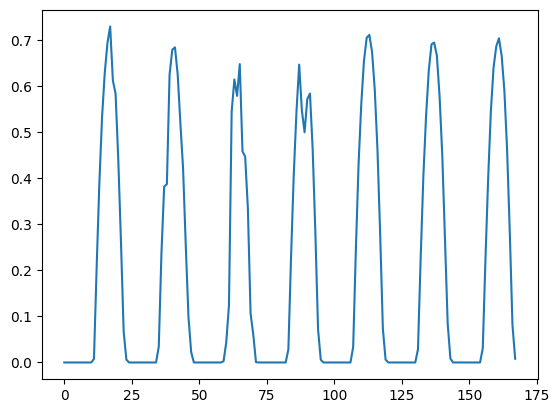

In [45]:
plt.plot(y_test_2[:, 0][16 : 184])

In [40]:
y_test_2

array([[0.000e+00, 0.000e+00, 0.000e+00, 2.100e-02, 2.181e-01, 4.026e-01,
        5.162e-01, 6.587e-01],
       [0.000e+00, 0.000e+00, 2.100e-02, 2.181e-01, 4.026e-01, 5.162e-01,
        6.587e-01, 7.136e-01],
       [0.000e+00, 2.100e-02, 2.181e-01, 4.026e-01, 5.162e-01, 6.587e-01,
        7.136e-01, 7.147e-01],
       [2.100e-02, 2.181e-01, 4.026e-01, 5.162e-01, 6.587e-01, 7.136e-01,
        7.147e-01, 6.763e-01],
       [2.181e-01, 4.026e-01, 5.162e-01, 6.587e-01, 7.136e-01, 7.147e-01,
        6.763e-01, 5.901e-01],
       [4.026e-01, 5.162e-01, 6.587e-01, 7.136e-01, 7.147e-01, 6.763e-01,
        5.901e-01, 4.559e-01],
       [5.162e-01, 6.587e-01, 7.136e-01, 7.147e-01, 6.763e-01, 5.901e-01,
        4.559e-01, 2.704e-01],
       [6.587e-01, 7.136e-01, 7.147e-01, 6.763e-01, 5.901e-01, 4.559e-01,
        2.704e-01, 6.250e-02],
       [7.136e-01, 7.147e-01, 6.763e-01, 5.901e-01, 4.559e-01, 2.704e-01,
        6.250e-02, 5.700e-03],
       [7.147e-01, 6.763e-01, 5.901e-01, 4.559e-01, 2.7

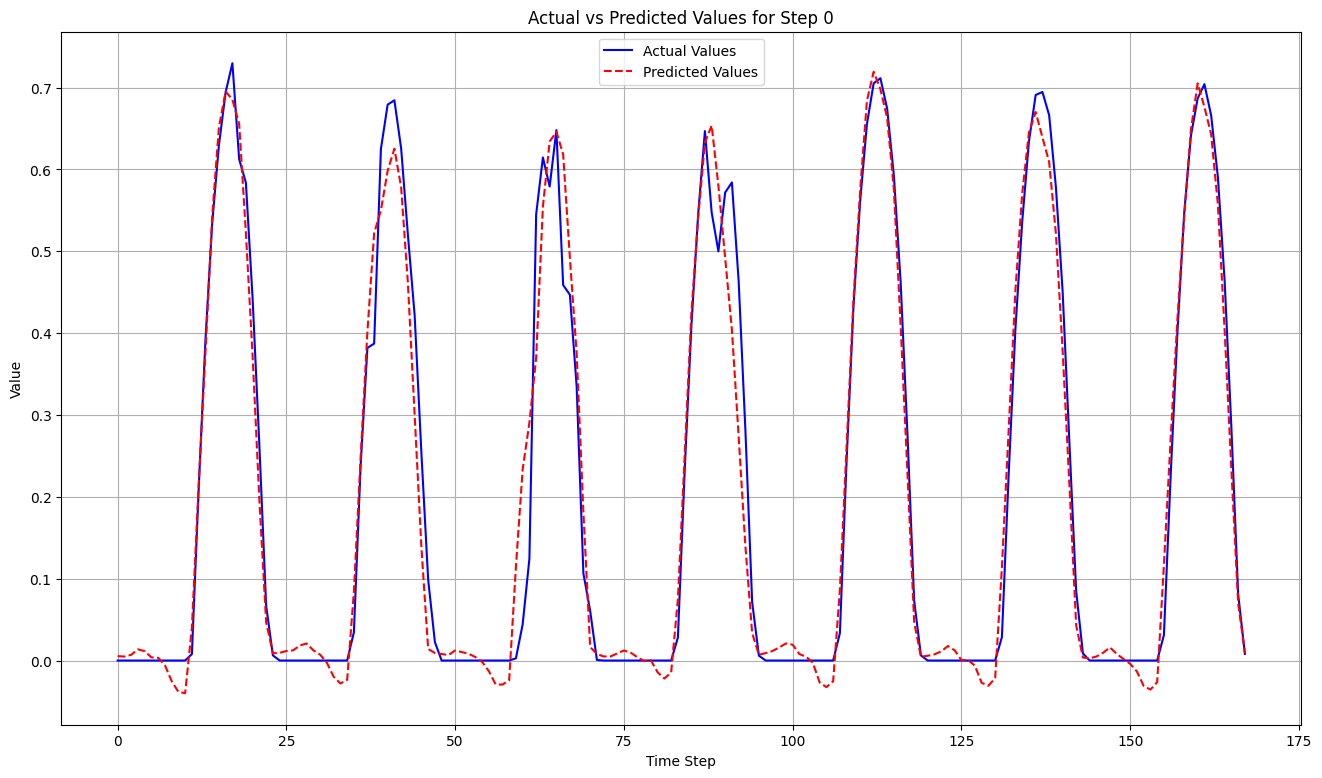

In [46]:

def plot_predictions_vs_real(predictions, real_values, step_index=0):
    plt.figure(figsize=(16, 9))
    
    y_pred_flat_1 = predictions[:, 1]
    y_pred_flat_2 = predictions[:, 2]
    y_pred_flat_3 = predictions[:, 3]
    y_pred_flat_4 = predictions[:, 4]

    y_pred_flat = predictions[:, step_index]
    y_real_flat = real_values[:, step_index]

    plt.plot(y_real_flat[16 : 184], label='Actual Values', color='blue')
    plt.plot(y_pred_flat[16 : 184], label='Predicted Values', color='red', linestyle='--')
    plt.title(f'Actual vs Predicted Values for Step {step_index}')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions_vs_real(test_predictions_2, y_test_2, step_index=0)


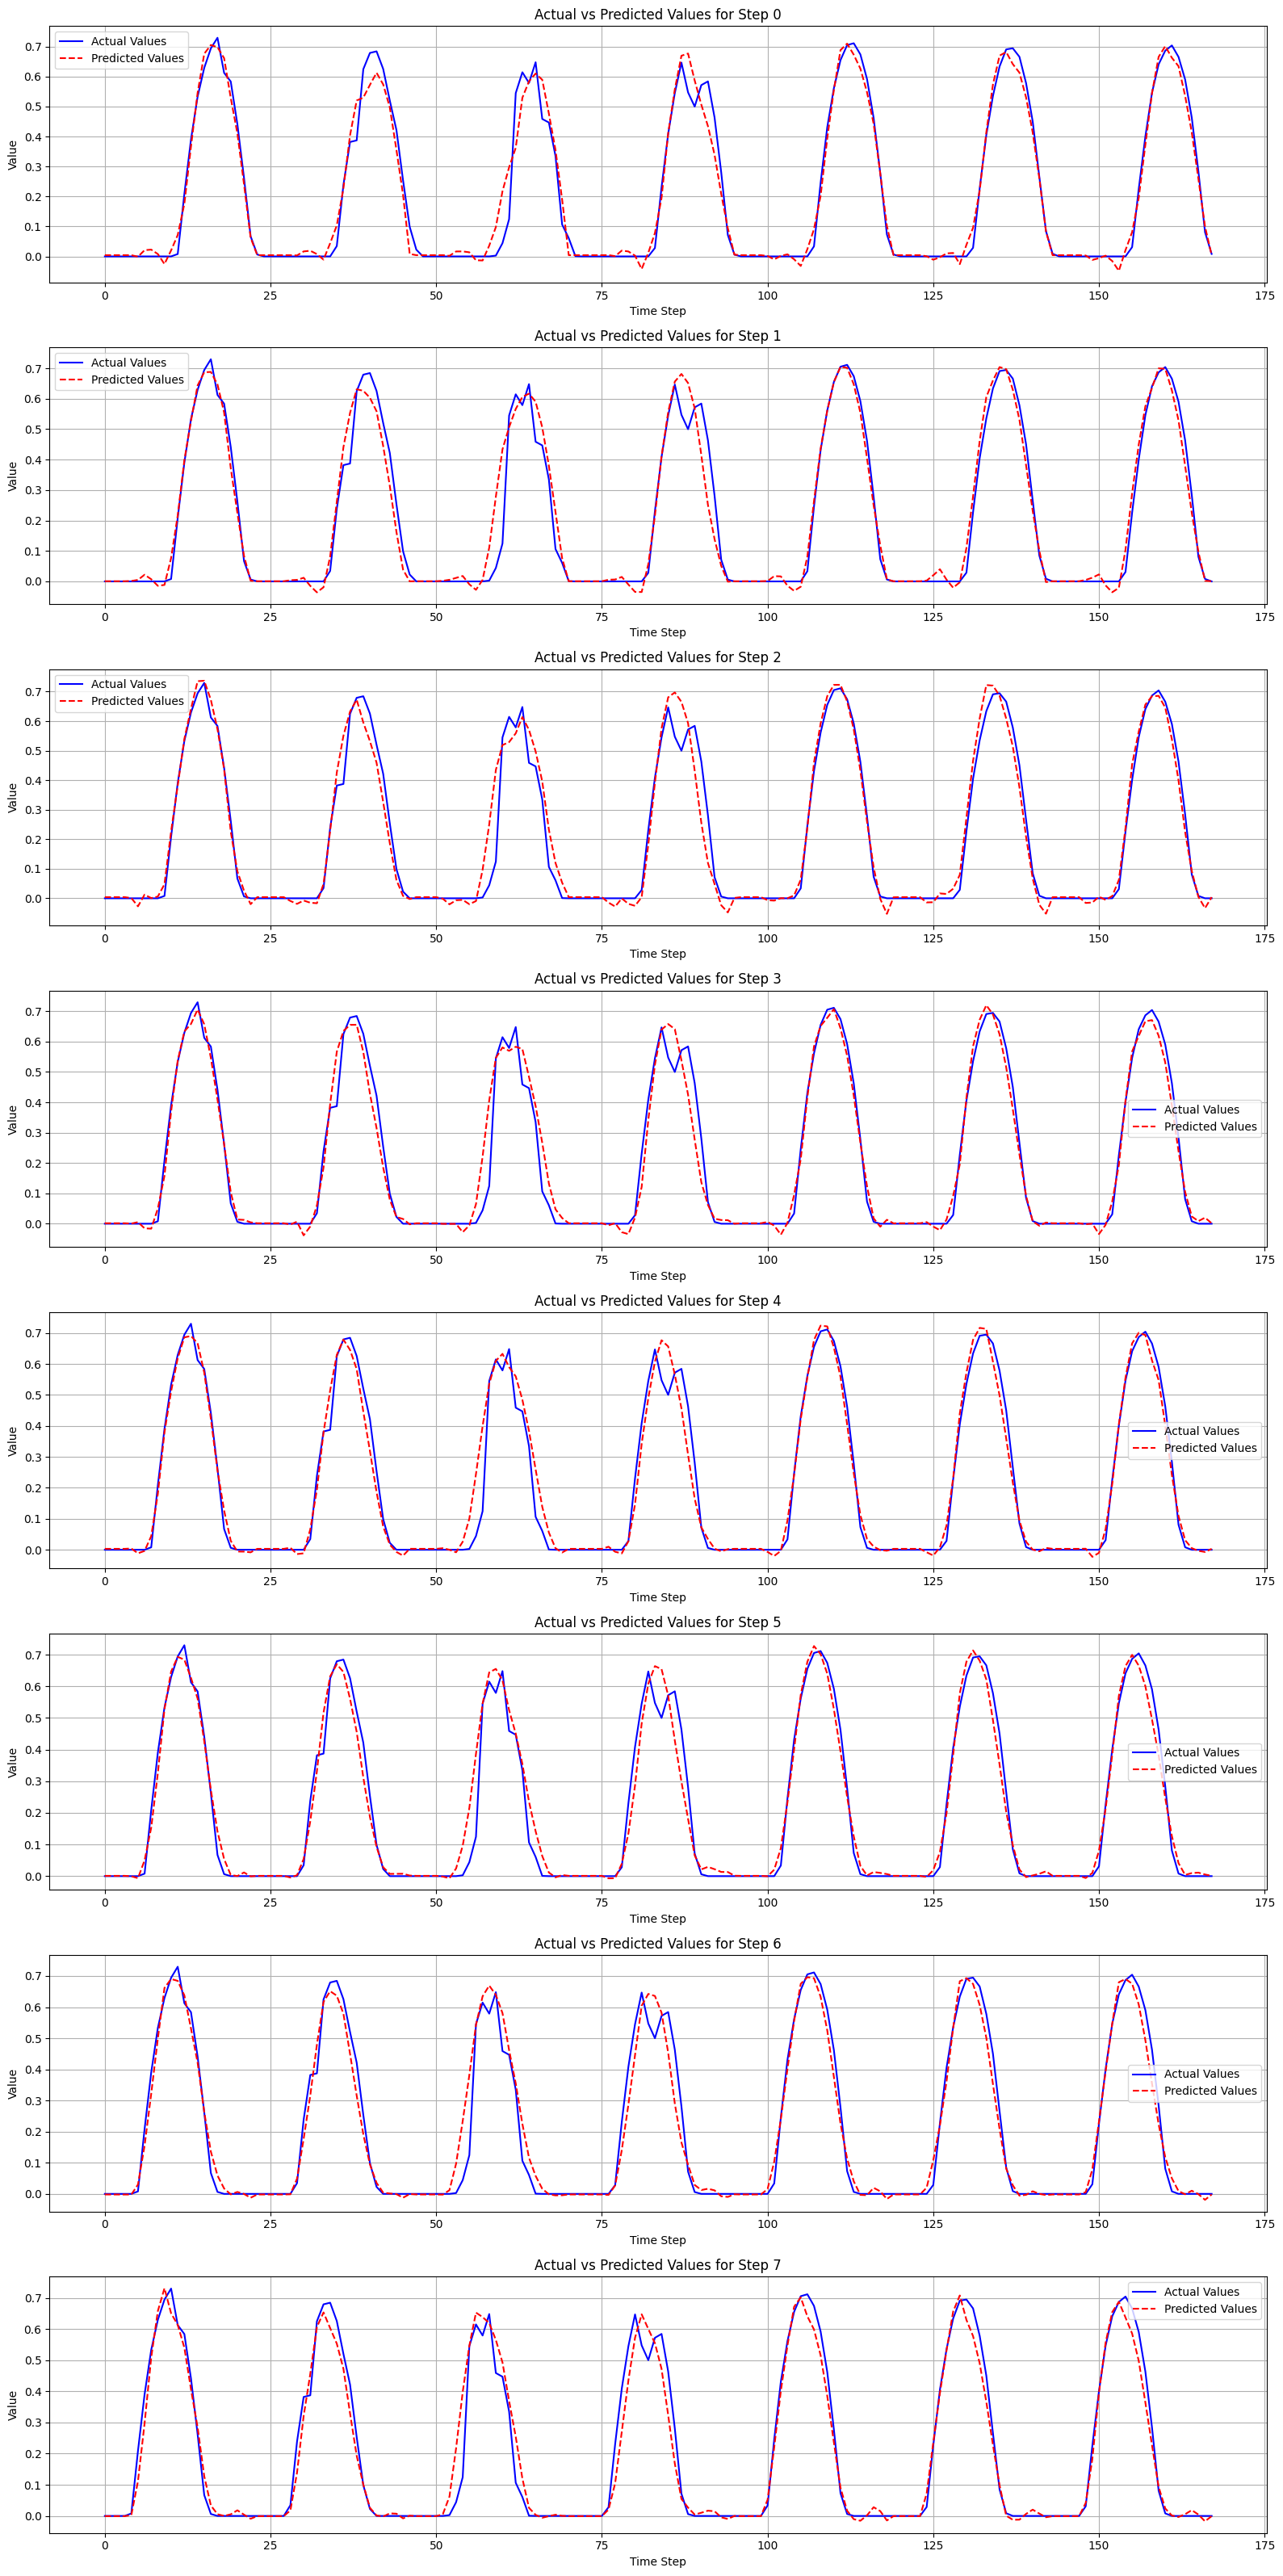

In [74]:
def plot_predictions_vs_real_multiple_steps(predictions, real_values, steps=8):
    plt.figure(figsize=(16, 4 * steps))
    
    for step_index in range(steps):
        plt.subplot(steps, 1, step_index + 1)
        y_pred_flat = predictions[:, step_index]
        y_real_flat = real_values[:, step_index]
        
        plt.plot(y_real_flat[16 : 184], label='Actual Values', color='blue')
        plt.plot(y_pred_flat[16 : 184], label='Predicted Values', color='red', linestyle='--')
        plt.title(f'Actual vs Predicted Values for Step {step_index}')
        plt.xlabel('Time Step')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_predictions_vs_real_multiple_steps(test_predictions_2, y_test_2, steps=8)


In [76]:
y_pred_flat = test_predictions_2.flatten()
y_real_flat = y_test_2.flatten()

In [77]:
mse = mean_squared_error(y_real_flat, y_pred_flat)
ss_res = mse * len(y_real_flat)
ss_tot = ((y_real_flat - y_real_flat.mean()) ** 2).sum()
r_squared = 1 - (ss_res / ss_tot)
print(f" Our model can explain the {round(r_squared, 10)* 100}% of total variability","\n","Root Mean Squared Error = ", np.sqrt(mse))

 Our model can explain the 88.27102948% of total variability 
 Root Mean Squared Error =  0.08532248078173152


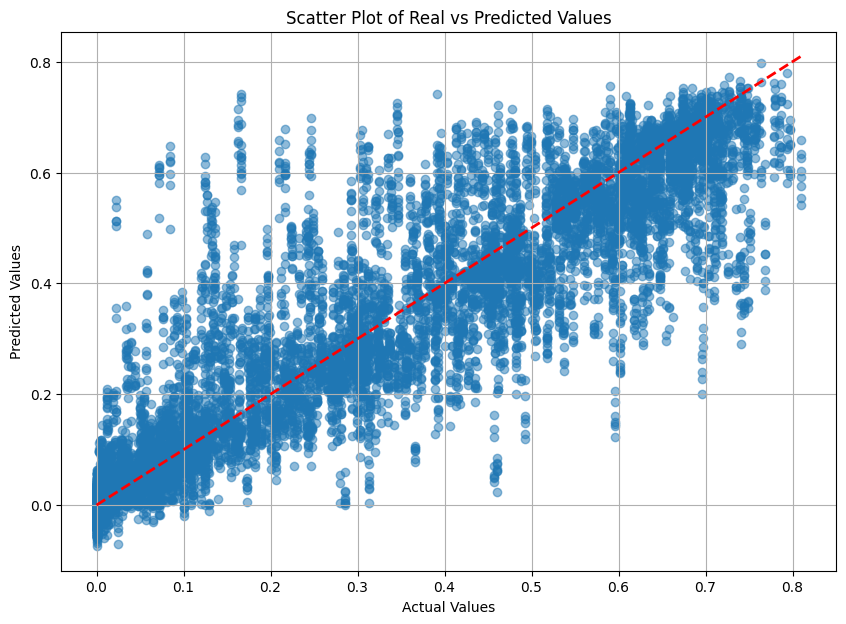

In [78]:
plt.figure(figsize=(10, 7))
plt.scatter(y_real_flat, y_pred_flat, alpha=0.5)
plt.plot([min(y_real_flat), max(y_real_flat)], [min(y_real_flat), max(y_real_flat)], color='red', linestyle='--', linewidth=2)
plt.title('Scatter Plot of Real vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()


In [ ]:
keras.layers.Attention(use_scale=False, score_mode="dot", dropout=0.0, seed=None, **kwargs)